# Advanced learning laboratory: sparse Gaussian graphical models

For a centered Gaussian distribution, zeros of the precision matrix $\Theta=\Sigma^{-1}$ encode pairwise conditional independences. Sparse structure learning can therefore be posed as the convex optimization problem

$$
\widehat\Theta
=\arg\min_{\Theta\succ0}
\left(-\log\det\Theta+\operatorname{tr}(S\Theta)+\lambda\|\Theta\|_{1,\mathrm{off}}\right),
$$

where $S$ is the empirical covariance matrix. This is the graphical lasso. It provides a useful Gaussian counterpart to the pseudo-likelihood and interaction-screening estimators developed for discrete graphical models.

In [1]:
CHAPTER_DIR="ch14"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / CHAPTER_DIR).exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})

def save_figure(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=240, bbox_inches="tight")
    print("Saved", stem)

def draw_dark_nodes(G, pos, labels=None, ax=None, node_size=1200, arrows=False, **kwargs):
    if ax is None: ax=plt.gca()
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="#303030", edgecolors="black", ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_color="white", font_size=13, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)
    return ax

def annotate_heatmap(ax, image, values, fmt=".2f"):
    arr=np.asarray(values)
    lo,hi=np.nanmin(arr),np.nanmax(arr)
    mid=(lo+hi)/2
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            color="white" if arr[i,j] < mid else "black"
            ax.text(j,i,format(arr[i,j],fmt),ha="center",va="center",color=color,fontsize=11)

In [2]:
from sklearn.covariance import GraphicalLasso
n=9
Theta=np.eye(n)*1.8
edges=[(0,1),(1,2),(2,3),(3,4),(1,5),(5,6),(6,7),(5,8)]
for k,(i,j) in enumerate(edges): Theta[i,j]=Theta[j,i]=(-1)**k*.32
# diagonal dominance guarantees SPD
Sigma=np.linalg.inv(Theta); S=350; X=RNG.multivariate_normal(np.zeros(n),Sigma,size=S)
alphas=np.logspace(-2.2,-.25,18); rows=[]; models=[]
truth=np.abs(Theta)>1e-10; np.fill_diagonal(truth,False)
for a in alphas:
    m=GraphicalLasso(alpha=a,max_iter=300).fit(X); P=m.precision_; pred=np.abs(P)>.045; np.fill_diagonal(pred,False)
    tp=np.sum(pred & truth)//2; fp=np.sum(pred & ~truth)//2; fn=np.sum(~pred & truth)//2
    prec=tp/max(tp+fp,1); rec=tp/max(tp+fn,1); rows.append((prec,rec)); models.append(P)
F=[2*p*r/max(p+r,1e-12) for p,r in rows]; ib=int(np.argmax(F)); Phat=models[ib]
print('selected alpha',alphas[ib],'precision/recall',rows[ib])

selected alpha 0.06797558301987454 precision/recall (np.float64(1.0), np.float64(0.75))


<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2498/3175963702.py:4: SyntaxWarning: invalid escape sequence '\l'
  axes[2].plot([r[1] for r in rows],[r[0] for r in rows],marker='o'); axes[2].scatter(rows[ib][1],rows[ib][0],s=90,marker='x'); axes[2].set_xlabel('recall'); axes[2].set_ylabel('precision'); axes[2].set_xlim(0,1.03); axes[2].set_ylim(0,1.03); axes[2].set_title('sparsity trade-off as $\lambda$ varies'); axes[2].grid(alpha=.25)


Saved ch14_03_graphical_lasso_recovery


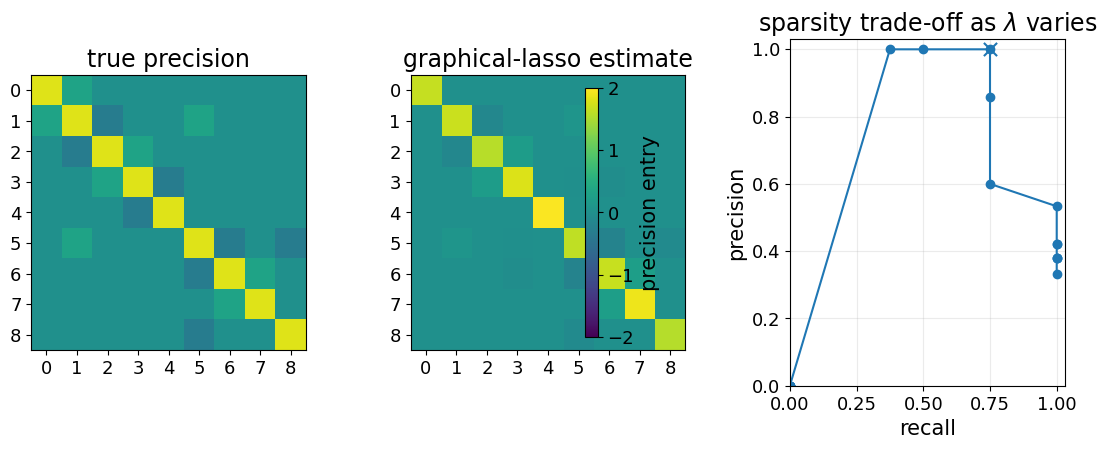

In [3]:
fig,axes=plt.subplots(1,3,figsize=(13,4.5));
for ax,M,t in zip(axes[:2],[Theta,Phat],['true precision','graphical-lasso estimate']):
    im=ax.imshow(M,vmin=-2,vmax=2); ax.set_title(t); ax.set_xticks(range(n)); ax.set_yticks(range(n));
axes[2].plot([r[1] for r in rows],[r[0] for r in rows],marker='o'); axes[2].scatter(rows[ib][1],rows[ib][0],s=90,marker='x'); axes[2].set_xlabel('recall'); axes[2].set_ylabel('precision'); axes[2].set_xlim(0,1.03); axes[2].set_ylim(0,1.03); axes[2].set_title('sparsity trade-off as $\lambda$ varies'); axes[2].grid(alpha=.25)
fig.colorbar(im,ax=axes[:2].ravel().tolist(),shrink=.72,label='precision entry'); fig.subplots_adjust(wspace=.38,right=.92); save_figure(fig,'ch14_03_graphical_lasso_recovery'); plt.show()

## Exercises

1. Repeat the experiment as the sample size changes. Plot the probability of exact support recovery.
2. Compare graphical lasso with nodewise sparse linear regression on the same data.
3. Add a latent common factor to all variables. Explain why marginalizing it can make the observed precision matrix dense.
4. Replace the unstructured $\ell_1$ penalty by a penalty favoring a known physical graph. Discuss the statistical trade-off when the prior graph is only approximately correct.